In [23]:
import sys, mlxtend
print("python:", sys.executable)
print("mlxtend:", mlxtend.__version__)

python: /Users/gizemtotkanli/.pyenv/versions/basket_ai/bin/python
mlxtend: 0.24.0


# 01 — Baseline EDA & Data Understanding

## Purpose
- Understand Turkish retail basket behavior
- Validate data integrity
- Establish hypotheses for downstream modeling

## Data Sources
- MarketSales transactional data (basket & item level)
- Generated basket tables (B1 phase)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

In [2]:
## 1. Data Loading

### We load basket-level and item-level datasets produced in the B1 phase.

### These tables form the foundation for all subsequent analysis.

basket_items = pd.read_parquet("../data/processed/baskets/basket_items.parquet")
baskets = pd.read_parquet("../data/processed/baskets/baskets.parquet")

print("basket_items shape:", basket_items.shape)
print("baskets shape:", baskets.shape)

display(baskets.head(3))
display(basket_items.head(3))

basket_items shape: (611107, 13)
baskets shape: (142611, 10)


,basket_id,customer_id,basket_date,total_items,distinct_items,total_amount,category_count,city,region,gender
0,15560,6476,2017-01-02,8.006,7,22.62,5,Batman,Güneydoğu Anadolu,K
1,15561,456620,2017-01-02,8.006,7,22.62,5,İstanbul,Marmara,K
2,15562,275882,2017-01-02,6.000,3,7.00,2,Adıyaman,Güneydoğu Anadolu,K


,basket_id,customer_id,basket_date,itemcode,AMOUNT,PRICE,item_total,CATEGORY_NAME1,CATEGORY_NAME2,CATEGORY_NAME3,CITY,REGION,GENDER
0,15560,6476,2017-01-02,8.0,2.0,2.65,5.3,İÇECEK,ÇAY KAHVE,SEKER TATLANDIRICI,Batman,Güneydoğu Anadolu,K
1,15560,6476,2017-01-02,1454.0,1.0,1.10,1.1,GIDA,MAKARNA,MAKARNA,Batman,Güneydoğu Anadolu,K
2,15560,6476,2017-01-02,6372.0,1.0,4.90,4.9,SÜT KAHVALTILIK,PEYNİR,KAŞAR PEYNİRİ,Batman,Güneydoğu Anadolu,K


In [3]:
## 2. Data Quality & Schema Validation

### We inspect data types, missing values, and basic descriptive statistics to validate dataset integrity before analysis.

def quality_report(df: pd.DataFrame, name: str):
    print(f"\n=== {name} ===")
    display(df.dtypes.to_frame("dtype"))
    miss = (df.isna().mean()*100).sort_values(ascending=False)
    display(miss.to_frame("% missing").head(15))
    display(df.describe(include="all").T.head(15))

quality_report(baskets, "baskets")
quality_report(basket_items, "basket_items")


=== baskets ===


,dtype
basket_id,int64
customer_id,object
basket_date,datetime64[ns]
total_items,float64
distinct_items,int64
total_amount,float64
category_count,int64
city,object
region,object
gender,object


,% missing
gender,3.029219
customer_id,3.026415
basket_id,0.000000
basket_date,0.000000
total_items,0.000000
distinct_items,0.000000
total_amount,0.000000
category_count,0.000000
city,0.000000
region,0.000000


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
basket_id,142611.0,NaN,NaN,NaN,87247.297046,15560.0,51220.5,86874.0,122527.5,351127.0,42661.646159
customer_id,138295,49316,2737,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
basket_date,142611,NaN,NaN,NaN,2017-02-16 20:00:58.463932928,2017-01-02 00:00:00,2017-01-26 00:00:00,2017-02-17 00:00:00,2017-03-10 00:00:00,2017-03-31 00:00:00,NaN
total_items,142611.0,NaN,NaN,NaN,5.442992,0.002,1.0,3.0,6.0,1017.0,9.002978
distinct_items,142611.0,NaN,NaN,NaN,3.83725,0.0,1.0,2.0,4.0,91.0,4.939327
total_amount,142611.0,NaN,NaN,NaN,17.379388,0.01,3.43,8.32,19.0,8556.0,42.43754
category_count,142611.0,NaN,NaN,NaN,2.677073,0.0,1.0,2.0,3.0,33.0,2.864347
city,142611,81,İstanbul,26360,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,142611,7,Marmara,41163,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,138291,2,K,73203,NaN,NaN,NaN,NaN,NaN,NaN,NaN



=== basket_items ===


,dtype
basket_id,int64
customer_id,object
basket_date,datetime64[ns]
itemcode,float64
AMOUNT,float64
PRICE,float64
item_total,float64
CATEGORY_NAME1,object
CATEGORY_NAME2,object
CATEGORY_NAME3,object


,% missing
CATEGORY_NAME3,34.275176
CATEGORY_NAME2,4.526049
GENDER,3.005038
customer_id,3.002257
itemcode,1.172626
CATEGORY_NAME1,1.172626
basket_id,0.000000
basket_date,0.000000
AMOUNT,0.000000
PRICE,0.000000


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
basket_id,611107.0,NaN,NaN,NaN,87347.543388,15560.0,51857.0,87169.0,122269.0,351127.0,42037.105507
customer_id,592760,49316,798326,151,NaN,NaN,NaN,NaN,NaN,NaN,NaN
basket_date,611107,NaN,NaN,NaN,2017-02-17 00:53:11.150486016,2017-01-02 00:00:00,2017-01-26 00:00:00,2017-02-17 00:00:00,2017-03-10 00:00:00,2017-03-31 00:00:00,NaN
itemcode,603941.0,NaN,NaN,NaN,9012.469698,6.0,3269.0,5719.0,14780.0,23602.0,7423.501236
AMOUNT,611107.0,NaN,NaN,NaN,1.270204,0.001,1.0,1.0,1.0,502.0,1.995301
PRICE,611107.0,NaN,NaN,NaN,3.959574,0.01,1.0,2.3,4.65,1799.0,6.683096
item_total,611107.0,NaN,NaN,NaN,4.055741,0.01,1.25,2.43,4.96,4278.0,11.956075
CATEGORY_NAME1,603941,12,GIDA,231973,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CATEGORY_NAME2,583448,63,BÜSKİVİ ÇEREZ,77218,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CATEGORY_NAME3,401649,155,BÜSKİVİ,47790,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
baskets["basket_date"] = pd.to_datetime(baskets["basket_date"], errors="coerce")

print("min date:", baskets["basket_date"].min())
print("max date:", baskets["basket_date"].max())

daily = baskets.groupby(baskets["basket_date"].dt.date).size()
display(daily.head())

min date: 2017-01-02 00:00:00
max date: 2017-03-31 00:00:00


basket_date
2017-01-02     226
2017-01-03     412
2017-01-04     237
2017-01-05    1032
2017-01-06    1199
dtype: int64

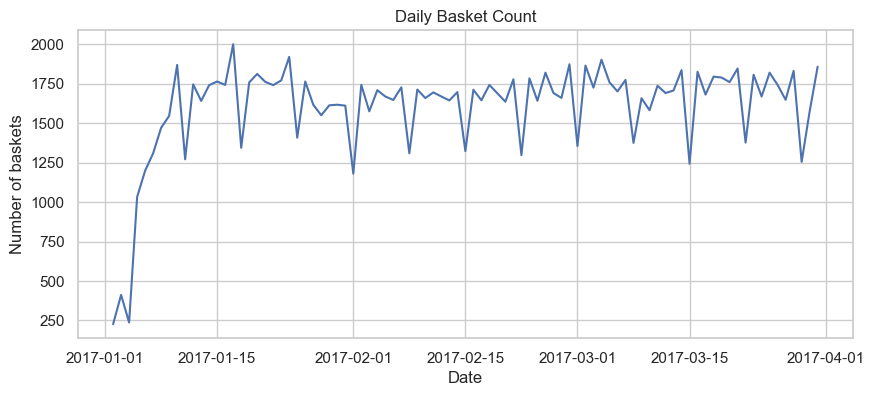

In [5]:
## 3. Temporal Coverage

### We examine the time range and daily basket activity to understand seasonality and data continuity.

plt.figure(figsize=(10,4))
daily.plot()
plt.title("Daily Basket Count")
plt.xlabel("Date")
plt.ylabel("Number of baskets")
plt.show()

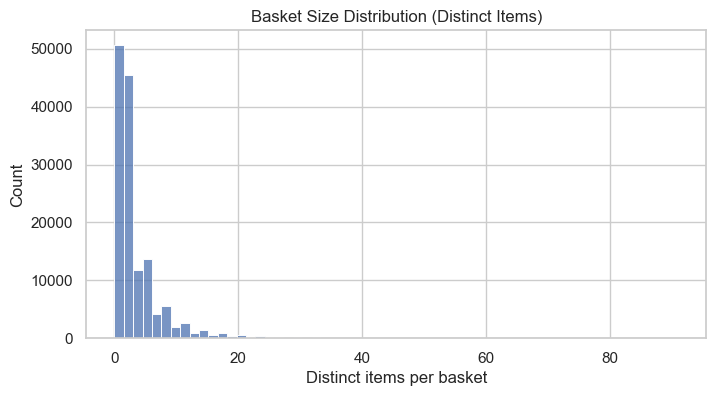

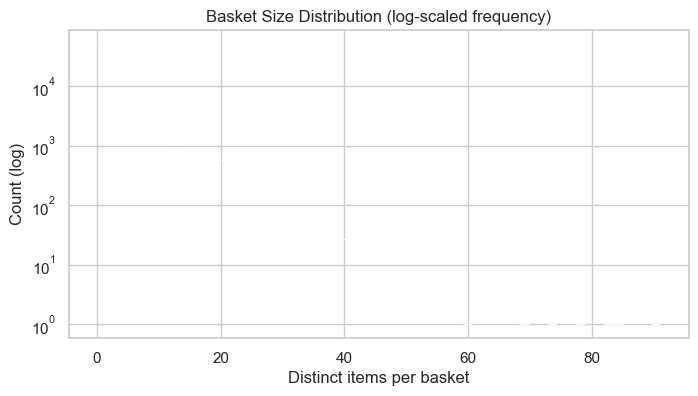

In [6]:
## 4. Hypothesis H1 — Basket Size Distribution

### **Hypothesis:**  

#### Basket size follows a heavy-tailed distribution, where a small fraction of baskets contain a disproportionately large number of items.

plt.figure(figsize=(8,4))
sns.histplot(baskets["distinct_items"], bins=60)
plt.title("Basket Size Distribution (Distinct Items)")
plt.xlabel("Distinct items per basket")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8,4))
sns.histplot(baskets["distinct_items"], bins=60, log_scale=(False, True))
plt.title("Basket Size Distribution (log-scaled frequency)")
plt.xlabel("Distinct items per basket")
plt.ylabel("Count (log)")
plt.show()

In [7]:
baskets["distinct_items"].describe(percentiles=[.5,.75,.9,.95,.99])

count    142611.000000
mean          3.837250
std           4.939327
min           0.000000
50%           2.000000
75%           4.000000
90%           8.000000
95%          12.000000
99%          25.000000
max          91.000000
Name: distinct_items, dtype: float64

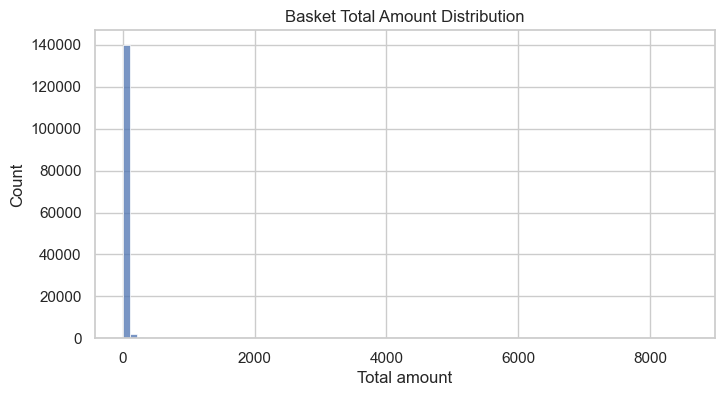

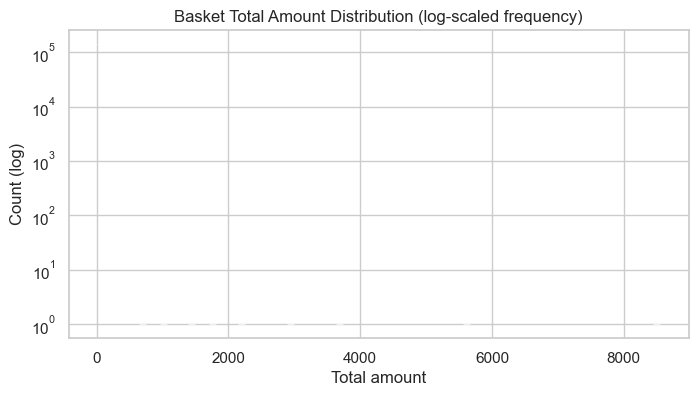

In [8]:
## 5. Hypothesis H2 — Basket Monetary Value

### **Hypothesis:**
 
#### A small number of high-value baskets ("whale baskets") contribute significantly to total revenue.

plt.figure(figsize=(8,4))
sns.histplot(baskets["total_amount"], bins=80)
plt.title("Basket Total Amount Distribution")
plt.xlabel("Total amount")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8,4))
sns.histplot(baskets["total_amount"], bins=80, log_scale=(False, True))
plt.title("Basket Total Amount Distribution (log-scaled frequency)")
plt.xlabel("Total amount")
plt.ylabel("Count (log)")
plt.show()

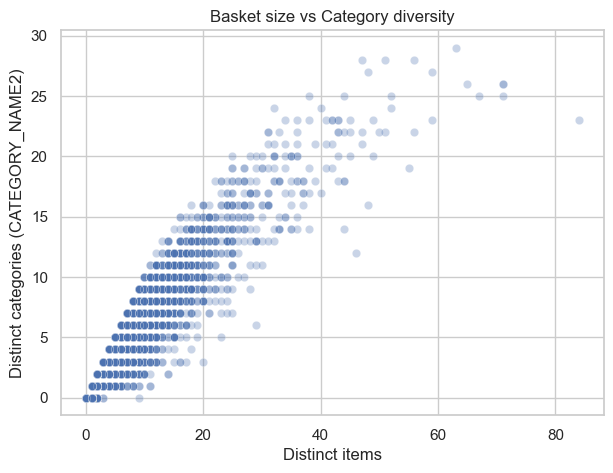

,distinct_items,category_count,total_amount
distinct_items,1.000000,0.934368,0.556826
category_count,0.934368,1.000000,0.526613
total_amount,0.556826,0.526613,1.000000


In [9]:
## 6. Hypothesis H3 — Category Diversity

### **Hypothesis:**  

#### Larger baskets exhibit higher category diversity, indicating cross-category shopping behavior.

plt.figure(figsize=(7,5))
sns.scatterplot(
    data=baskets.sample(min(len(baskets), 20000), random_state=42),
    x="distinct_items",
    y="category_count",
    alpha=0.3
)
plt.title("Basket size vs Category diversity")
plt.xlabel("Distinct items")
plt.ylabel("Distinct categories (CATEGORY_NAME2)")
plt.show()

baskets[["distinct_items","category_count","total_amount"]].corr()

In [10]:
## 7. Basket-Level Patterns

### We transform basket-item relationships into transaction format to enable pattern mining and association rule discovery.

#### **Output:** `transactions` (each basket → list of itemcodes), plus a one-hot encoded basket-item matrix.

top_items = basket_items["itemcode"].value_counts().head(20)
top_items

itemcode
7.0        9122
5694.0     6018
5715.0     5718
5701.0     5611
8.0        5242
5716.0     4631
20885.0    4101
5717.0     4093
5693.0     3934
5461.0     3925
5518.0     3808
5711.0     3632
5362.0     3566
3190.0     3253
5741.0     2900
22772.0    2692
263.0      2588
5702.0     2561
5780.0     2471
21584.0    2419
Name: count, dtype: int64

In [11]:
[c for c in basket_items.columns if "CATEGORY" in c.upper()]

['CATEGORY_NAME1', 'CATEGORY_NAME2', 'CATEGORY_NAME3']

In [12]:
basket_items.columns

Index(['basket_id', 'customer_id', 'basket_date', 'itemcode', 'AMOUNT',
       'PRICE', 'item_total', 'CATEGORY_NAME1', 'CATEGORY_NAME2',
       'CATEGORY_NAME3', 'CITY', 'REGION', 'GENDER'],
      dtype='object')

In [13]:
# Each basket as a list of itemcodes (transaction format)

transactions = (
    basket_items
    .groupby("basket_id")["itemcode"]
    .apply(list)
)

transactions.head()

basket_id
15560    [8.0, 1454.0, 6372.0, 8583.0, 8639.0, 13519.0,...
15561    [8.0, 1454.0, 6372.0, 8583.0, 8639.0, 13519.0,...
15562                                [7.0, 1806.0, 2123.0]
15563                    [2510.0, 5461.0, 5694.0, 21713.0]
15564                                     [2704.0, 2704.0]
Name: itemcode, dtype: object

In [14]:
# Basic sanity checks

print("Number of baskets:", transactions.shape[0])
print("Average items per basket:", transactions.apply(len).mean())
print("Max items in a basket:", transactions.apply(len).max())

Number of baskets: 142611
Average items per basket: 4.2851322829234775
Max items in a basket: 110


In [15]:
import sys
sys.executable

'/Users/gizemtotkanli/.pyenv/versions/basket_ai/bin/python'

In [16]:
## 8. Association Rules

### We apply FP-Growth to identify frequent itemsets and derive association rules using support, confidence, and lift metrics.

#### → Kurallar tablosu

from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

basket_binary = pd.DataFrame(te_array, columns=te.columns_)
basket_binary.shape

(142611, 16533)

In [17]:
from mlxtend.frequent_patterns import fpgrowth

freq_items = fpgrowth(
    basket_binary,
    min_support=0.005,   # %0.5 — veri büyük olduğu için mantıklı eşik
    use_colnames=True
)

freq_items["length"] = freq_items["itemsets"].apply(len)
freq_items.sort_values("support", ascending=False).head(10)

,support,itemsets,length
2,0.061229,(7.0),1
3,0.041245,(5694.0),1
23,0.039359,(5715.0),1
31,0.038146,(5701.0),1
0,0.035544,(8.0),1
21,0.031814,(5716.0),1
20,0.028343,(5717.0),1
25,0.027074,(5693.0),1
26,0.026604,(20885.0),1
4,0.026436,(5461.0),1


In [18]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    freq_items,
    metric="lift",
    min_threshold=1.2
)

rules = rules.sort_values(
    ["lift", "confidence", "support"],
    ascending=False
)

rules.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
22,(6261.0),(5461.0),0.014206,0.026436,0.006213,0.437315,16.542683,1.0,0.005837,1.730212,0.953090,0.180448,0.422036,0.336164
23,(5461.0),(6261.0),0.026436,0.014206,0.006213,0.235013,16.542683,1.0,0.005837,1.288641,0.965062,0.180448,0.223989,0.336164
24,(6261.0),(5518.0),0.014206,0.025755,0.005329,0.375123,14.564858,1.0,0.004963,1.559099,0.944763,0.153877,0.358604,0.291019
25,(5518.0),(6261.0),0.025755,0.014206,0.005329,0.206915,14.564858,1.0,0.004963,1.242986,0.955963,0.153877,0.195486,0.291019
26,(5696.0),(5694.0),0.013477,0.041245,0.005862,0.434964,10.545833,1.0,0.005306,1.696802,0.917542,0.119977,0.410656,0.288546
27,(5694.0),(5696.0),0.041245,0.013477,0.005862,0.142129,10.545833,1.0,0.005306,1.149966,0.944116,0.119977,0.130409,0.288546
17,(5518.0),(5461.0),0.025755,0.026436,0.007061,0.274163,10.370990,1.0,0.006380,1.341299,0.927464,0.156464,0.254454,0.270636
16,(5461.0),(5518.0),0.026436,0.025755,0.007061,0.267109,10.370990,1.0,0.006380,1.329317,0.928112,0.156464,0.247734,0.270636
8,(5707.0),(5694.0),0.015623,0.041245,0.006395,0.409336,9.924478,1.0,0.005751,1.623181,0.913511,0.126702,0.383926,0.282193
9,(5694.0),(5707.0),0.041245,0.015623,0.006395,0.155049,9.924478,1.0,0.005751,1.165011,0.937924,0.126702,0.141639,0.282193


In [19]:
## 9. Category-Level Insights

### To improve interpretability, we map item-level rules to category-level patterns and extract business-relevant insights.

### We convert item rules into category rules (e.g., "ÇAY KAHVE → ŞEKER TATLANDIRICI") for easier storytelling and dashboarding.

def format_itemset(s):
    return ", ".join(str(x) for x in sorted(list(s)))

rules_readable = rules.assign(
    antecedents_str=rules["antecedents"].apply(format_itemset),
    consequents_str=rules["consequents"].apply(format_itemset)
)

rules_readable[
    ["antecedents_str", "consequents_str", "support", "confidence", "lift"]
].head(10)

,antecedents_str,consequents_str,support,confidence,lift
22,6261.0,5461.0,0.006213,0.437315,16.542683
23,5461.0,6261.0,0.006213,0.235013,16.542683
24,6261.0,5518.0,0.005329,0.375123,14.564858
25,5518.0,6261.0,0.005329,0.206915,14.564858
26,5696.0,5694.0,0.005862,0.434964,10.545833
27,5694.0,5696.0,0.005862,0.142129,10.545833
17,5518.0,5461.0,0.007061,0.274163,10.370990
16,5461.0,5518.0,0.007061,0.267109,10.370990
8,5707.0,5694.0,0.006395,0.409336,9.924478
9,5694.0,5707.0,0.006395,0.155049,9.924478


In [20]:
# Mapping from itemcode to CATEGORY_NAME2 (category-level representation)

item_to_cat = (
    basket_items
    .drop_duplicates("itemcode")
    .set_index("itemcode")["CATEGORY_NAME2"]
)

def map_to_category(itemset):
    return tuple(sorted(set(item_to_cat.get(i, "UNKNOWN") for i in itemset)))

rules_cat = rules.assign(
    antecedent_cats=rules["antecedents"].apply(map_to_category),
    consequent_cats=rules["consequents"].apply(map_to_category),
)

rules_cat[
    ["antecedent_cats", "consequent_cats", "support", "confidence", "lift"]
].head(10)

,antecedent_cats,consequent_cats,support,confidence,lift
22,"(SEBZE,)","(SEBZE,)",0.006213,0.437315,16.542683
23,"(SEBZE,)","(SEBZE,)",0.006213,0.235013,16.542683
24,"(SEBZE,)","(SEBZE,)",0.005329,0.375123,14.564858
25,"(SEBZE,)","(SEBZE,)",0.005329,0.206915,14.564858
26,"(SEBZE,)","(SEBZE,)",0.005862,0.434964,10.545833
27,"(SEBZE,)","(SEBZE,)",0.005862,0.142129,10.545833
17,"(SEBZE,)","(SEBZE,)",0.007061,0.274163,10.370990
16,"(SEBZE,)","(SEBZE,)",0.007061,0.267109,10.370990
8,"(SEBZE,)","(SEBZE,)",0.006395,0.409336,9.924478
9,"(SEBZE,)","(SEBZE,)",0.006395,0.155049,9.924478


In [21]:
from pathlib import Path
import pandas as pd
import numpy as np

OUT = Path("../dash_app/data")
OUT.mkdir(parents=True, exist_ok=True)

def _find_df_with_cols(required_any, required_all=None):
    required_all = required_all or []
    for name, obj in list(globals().items()):
        if isinstance(obj, pd.DataFrame) and not obj.empty:
            cols = set(map(str, obj.columns))
            if all(c in cols for c in required_all) and any(c in cols for c in required_any):
                return name, obj
    return None, None

# 1) baskets benzeri DF: basket_id + basket_date + (total_amount opsiyonel) + customer_id opsiyonel
baskets_name, baskets_df = _find_df_with_cols(
    required_any=["basket_date", "date"],
    required_all=["basket_id"]
)

if baskets_df is None:
    print("⚠️ baskets DF bulunamadı (basket_id + basket_date). EDA export atlandı.")
else:
    df = baskets_df.copy()
    # date kolonu normalize
    if "basket_date" in df.columns:
        df["date"] = pd.to_datetime(df["basket_date"]).dt.date
    elif "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"]).dt.date
    else:
        df["date"] = pd.to_datetime(df.iloc[:,0]).dt.date  # son çare

    # sepet sayısı
    ts = df.groupby("date").agg(
        baskets=("basket_id","nunique"),
        distinct_customers=("customer_id","nunique") if "customer_id" in df.columns else ("basket_id","nunique"),
    ).reset_index()

    # revenue/aov varsa
    if "total_amount" in df.columns:
        rev = df.groupby("date")["total_amount"].sum().reset_index(name="revenue")
        ts = ts.merge(rev, on="date", how="left")
        ts["aov"] = ts["revenue"] / ts["baskets"]
    else:
        ts["revenue"] = np.nan
        ts["aov"] = np.nan

    ts.to_csv(OUT / "eda_timeseries.csv", index=False)
    print("✅ wrote", (OUT/"eda_timeseries.csv").resolve(), "from", baskets_name)

# 2) basket_items benzeri DF: basket_id + item_total/price/amount + CATEGORY_NAME1 opsiyonel
bi_name, bi_df = _find_df_with_cols(
    required_any=["CATEGORY_NAME1", "category", "item_total", "PRICE"],
    required_all=["basket_id"]
)

if bi_df is None:
    print("⚠️ basket_items DF bulunamadı (basket_id + ...). category export atlandı.")
else:
    df = bi_df.copy()
    # kategori kolonu
    cat_col = None
    for c in ["CATEGORY_NAME1", "category"]:
        if c in df.columns:
            cat_col = c
            break

    # revenue kolonu
    rev_col = None
    for c in ["item_total", "total", "PRICE"]:
        if c in df.columns:
            rev_col = c
            break

    if cat_col:
        top_cat = df.groupby(cat_col).agg(
            orders=("basket_id","nunique"),
            revenue=(rev_col,"sum") if rev_col else ("basket_id","nunique")
        ).reset_index().rename(columns={cat_col:"category"})
        top_cat = top_cat.sort_values("orders", ascending=False).head(20)
        top_cat.to_csv(OUT / "top_categories.csv", index=False)
        print("✅ wrote", (OUT/"top_categories.csv").resolve(), "from", bi_name)
    else:
        print("⚠️ Kategori kolonu yok; top_categories.csv üretilmedi.")

# 3) basket size dist (baskets DF içinde total_items varsa)
if baskets_df is not None and "total_items" in baskets_df.columns:
    bs = (baskets_df["total_items"].value_counts()
          .sort_index()
          .reset_index()
          .rename(columns={"index":"basket_size","total_items":"count"}))
    bs.to_csv(OUT / "basket_size_dist.csv", index=False)
    print("✅ wrote", (OUT/"basket_size_dist.csv").resolve())
else:
    print("ℹ️ baskets.total_items yok; basket_size_dist.csv opsiyonel kaldı.")

✅ wrote /Users/gizemtotkanli/projects/basket_ai/dash_app/data/eda_timeseries.csv from basket_items
✅ wrote /Users/gizemtotkanli/projects/basket_ai/dash_app/data/top_categories.csv from basket_items
ℹ️ baskets.total_items yok; basket_size_dist.csv opsiyonel kaldı.


In [22]:
import sys, site
import mlxtend

print("python:", sys.executable)
print("mlxtend:", mlxtend.__version__)
print("site:", site.getsitepackages()[:2])

python: /Users/gizemtotkanli/.pyenv/versions/basket_ai/bin/python
mlxtend: 0.24.0
site: ['/Users/gizemtotkanli/.pyenv/versions/basket_ai/lib/python3.12/site-packages']
